In [1]:
import json
import pandas as pd
import numpy as np

def load_summary(path, name):
    with open(path) as f:
        data = json.load(f)
    
    rows = []
    for cls, vals in data["mean"].items():
        rows.append({
            "class": cls,
            "Dice": vals["Dice"],
            "IoU": vals["IoU"],
            "method": name
        })
    
    return pd.DataFrame(rows), data

df_default, data_default = load_summary("summary_default.json", "default")
df_cldice, data_cldice   = load_summary("summary_cldice.json", "clDice")

df_all = pd.concat([df_default, df_cldice])

In [2]:
LABELS = {
    "1":"BA","2":"R-P1P2","3":"L-P1P2","4":"R-ICA","5":"R-M1","6":"L-ICA",
    "7":"L-M1","8":"R-Pcom","9":"L-Pcom","10":"Acom","11":"R-A1A2","12":"L-A1A2",
    "13":"R-A3","14":"L-A3","15":"3rd-A2","16":"3rd-A3","17":"R-M2","18":"R-M3",
    "19":"L-M2","20":"L-M3","21":"R-P3P4","22":"L-P3P4","23":"R-VA","24":"L-VA",
    "25":"R-SCA","26":"L-SCA","27":"R-AICA","28":"L-AICA","29":"R-PICA","30":"L-PICA",
    "31":"R-AChA","32":"L-AChA","33":"R-OA","34":"L-OA","35":"VoG","36":"StS",
    "37":"ICVs","38":"R-BVR","39":"L-BVR","40":"SSS",
}

pivot_dice = df_all.pivot(index="class", columns="method", values="Dice")

pivot_dice = pivot_dice.sort_index(key=lambda x: x.astype(int))

pivot_dice.index = [f"{LABELS.get(i, i)}" for i in pivot_dice.index]

display(pivot_dice.round(4))

method,clDice,default
BA,0.9235,0.9173
R-P1P2,0.6539,0.6235
L-P1P2,0.8372,0.7682
R-ICA,0.6338,0.6298
R-M1,0.7128,0.6324
L-ICA,0.6610,0.6541
L-M1,0.6162,0.4294
R-Pcom,0.7488,0.7494
L-Pcom,0.1066,0.1373
Acom,0.4559,0.4518


In [3]:
summary_stats = df_all.groupby("method")["Dice"].agg(["mean", "std"])
display(summary_stats)

,mean,std
method,,
clDice,0.543933,0.252129
default,0.476703,0.257892


In [4]:
def build_case_df(data, name):
    rows = []
    for entry in data["metric_per_case"]:
        case = entry["prediction_file"].split("/")[-1].replace(".nii.gz", "")
        
        vals = [
            entry["metrics"][cls]["Dice"]
            for cls in entry["metrics"]
            if entry["metrics"][cls]["n_ref"] > 0
            and entry["metrics"][cls]["Dice"] == entry["metrics"][cls]["Dice"]
        ]
        
        rows.append({
            "case": case,
            "mean_dice": np.mean(vals),
            "method": name
        })
    
    return pd.DataFrame(rows)

case_default = build_case_df(data_default, "default")
case_cldice  = build_case_df(data_cldice, "clDice")

case_df = pd.concat([case_default, case_cldice])
pivot_cases = case_df.pivot(index="case", columns="method", values="mean_dice")

pivot_cases["diff (clDice - default)"] = pivot_cases["clDice"] - pivot_cases["default"]

display(pivot_cases)

method,clDice,default,diff (clDice - default)
case,,,
topcow_ct_024,0.377408,0.324724,0.052684
topcow_ct_025,0.726765,0.696573,0.030192
topcow_ct_026,0.761621,0.675989,0.085632
topcow_ct_027,0.660117,0.561265,0.098851


In [ ]:
def build_per_segment_df(data, name):
    rows = []
    for entry in data["metric_per_case"]:
        case = entry["prediction_file"].split("/")[-1].replace(".nii.gz", "")
        for cls, vals in entry["metrics"].items():
            if vals["n_ref"] > 0:
                rows.append({
                    "case": case,
                    "class": LABELS.get(cls, cls),
                    "Dice": vals["Dice"],
                    "IoU": vals["IoU"],
                    "method": name
                })
    return pd.DataFrame(rows)

seg_default = build_per_segment_df(data_default, "default")
seg_cldice  = build_per_segment_df(data_cldice, "clDice")

# Per case: pivot so each row is a (case, class) and columns are methods
pivot_seg = seg_default.merge(seg_cldice, on=["case", "class"], suffixes=("_default", "_clDice"))

# Show results per test volume
for case, group in pivot_seg.groupby("case"):
    print(f"\n── {case} ──")
    display(group[["class", "Dice_default", "Dice_clDice"]].set_index("class").round(4))


── topcow_ct_024 ──


,Dice_default,Dice_clDice
class,,
BA,0.8813,0.8597
Acom,0.7491,0.7633
R-A1A2,0.0107,0.0000
L-A1A2,0.0000,0.0011
R-A3,0.4510,0.4083
L-A3,0.0848,0.1963
R-M2,0.5223,0.6338
R-M3,0.3068,0.4546
L-M2,0.0000,0.0000



── topcow_ct_025 ──


,Dice_default,Dice_clDice
class,,
BA,0.9392,0.9449
Acom,0.7851,0.8166
R-A1A2,0.8030,0.8557
L-A1A2,0.7943,0.8341
R-A3,0.8733,0.9061
L-A3,0.8382,0.8657
R-M2,0.5666,0.7697
R-M3,0.4837,0.6871
L-M2,0.7353,0.8400



── topcow_ct_026 ──


,Dice_default,Dice_clDice
class,,
BA,0.9037,0.9378
R-A1A2,0.9433,0.9306
L-A1A2,0.9225,0.9266
R-A3,0.6676,0.8012
L-A3,0.7162,0.8599
R-M2,0.6855,0.8478
R-M3,0.4780,0.6808
L-M2,0.6559,0.8346
R-P1P2,0.7690,0.8316



── topcow_ct_027 ──


,Dice_default,Dice_clDice
class,,
BA,0.9450,0.9515
Acom,0.2727,0.2439
R-A1A2,0.5411,0.6694
L-A1A2,0.7134,0.7453
R-A3,0.6603,0.7078
L-A3,0.2513,0.4073
R-M2,0.4250,0.3710
R-M3,0.4120,0.4363
L-M2,0.0066,0.4521


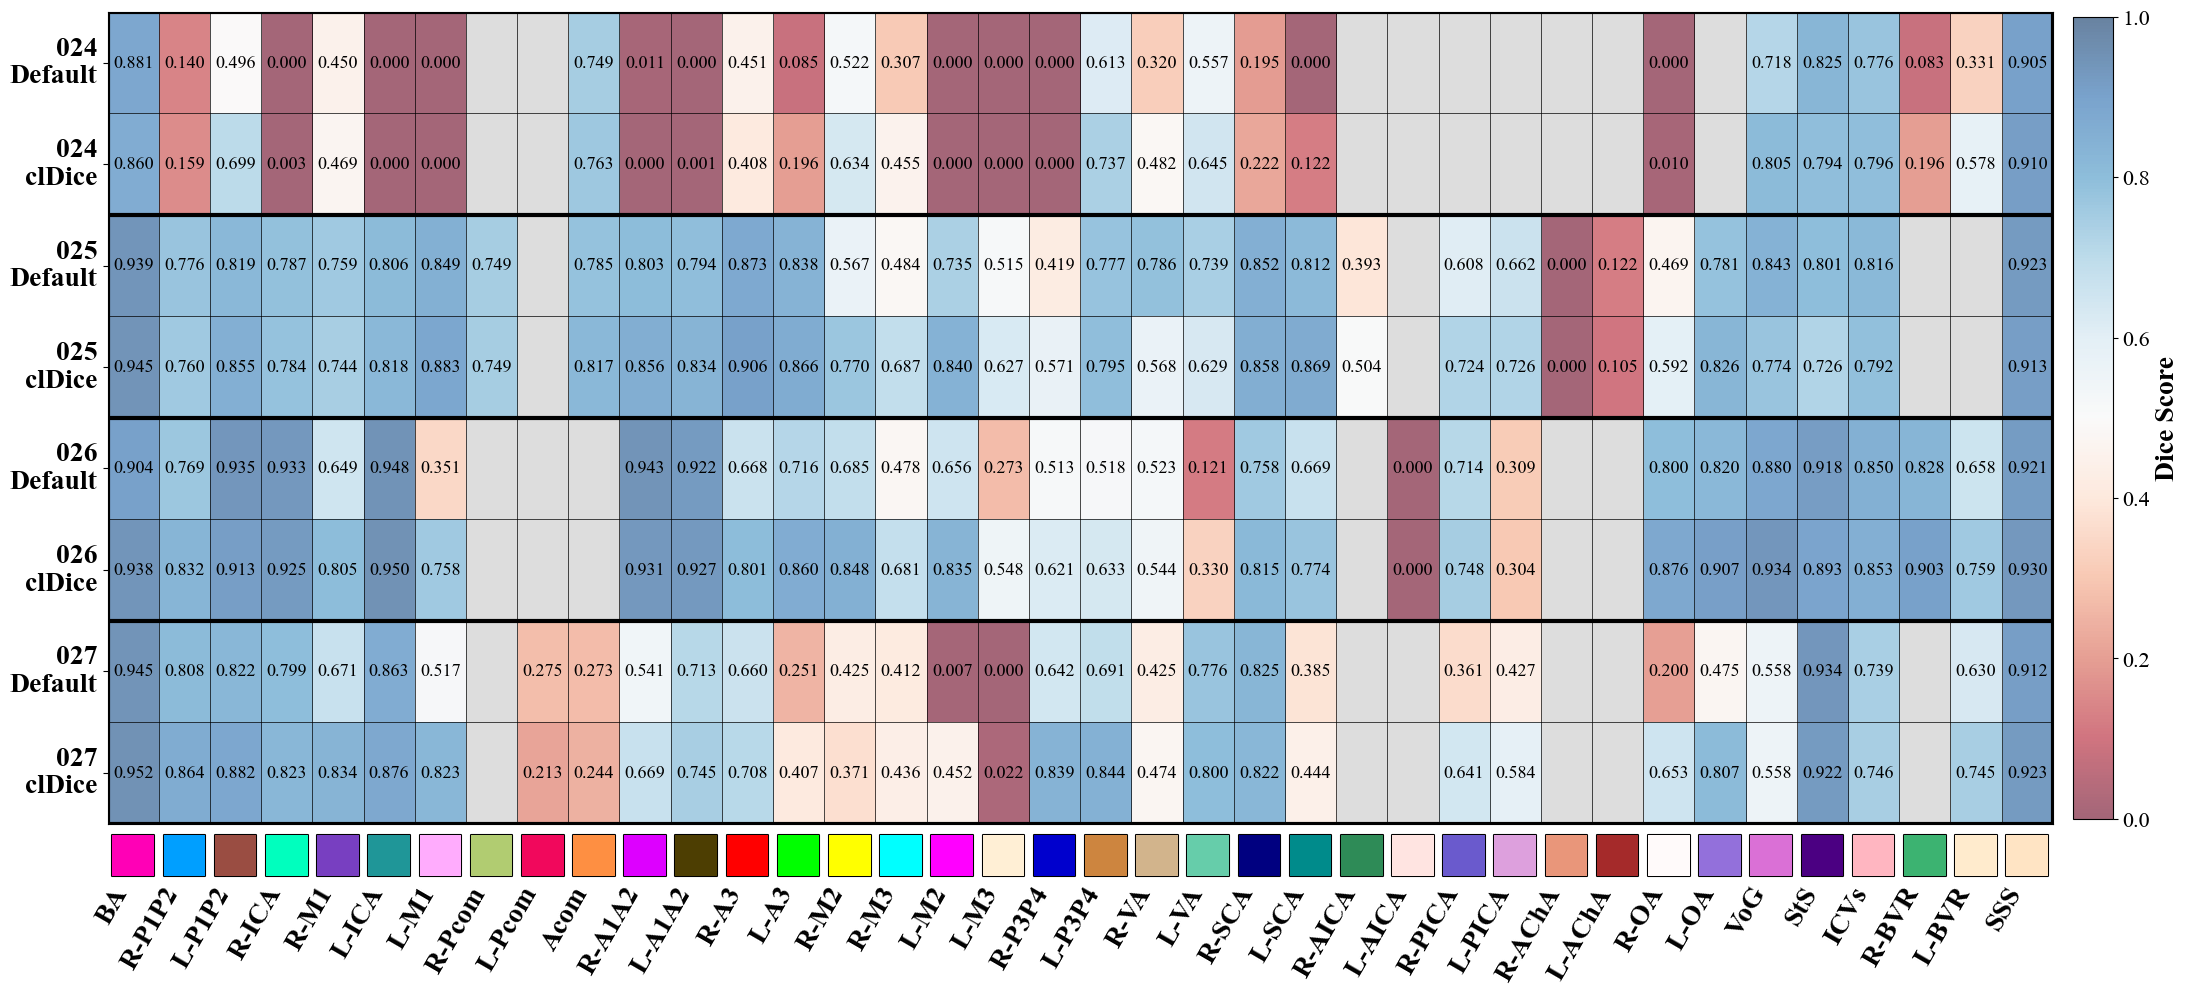

In [202]:
SEG_COLORS = {
    "1": (255,0,182),   "2": (0,159,255),   "3": (154,77,66),   "4": (0,255,190),
    "5": (120,63,193),  "6": (31,150,152),  "7": (255,172,253), "8": (177,204,113),
    "9": (241,8,92),    "10": (254,143,66), "11": (221,0,255),  "12": (77,62,2),
    "13": (255,0,0),    "14": (0,255,0),    "15": (2,173,36),   "16": (0,0,255),
    "17": (255,255,0),  "18": (0,255,255),  "19": (255,0,255),  "20": (255,239,213),
    "21": (0,0,205),    "22": (205,133,63), "23": (210,180,140),"24": (102,205,170),
    "25": (0,0,128),    "26": (0,139,139),  "27": (46,139,87),  "28": (255,228,225),
    "29": (106,90,205), "30": (221,160,221),"31": (233,150,122),"32": (165,42,42),
    "33": (255,250,250),"34": (147,112,219),"35": (218,112,214),"36": (75,0,130),
    "37": (255,182,193),"38": (60,179,113), "39": (255,235,205),"40": (255,228,196),
}

plt.rcParams["font.family"] = "Times New Roman"

LABELS_INV = {v: k for k, v in LABELS.items()}

import matplotlib.pyplot as plt
import numpy as np
import matplotlib.colors as mcolors
import matplotlib.patheffects as pe

long = pivot_seg.melt(
    id_vars=["case", "class"],
    value_vars=["Dice_default", "Dice_clDice"],
    var_name="method",
    value_name="Dice"
)
long["method"] = long["method"].str.replace("Dice_default", "Default").str.replace("Dice_clDice", "clDice")

pivot_heat = long.pivot_table(index=["case", "method"], columns="class", values="Dice")

desired_order = [
    f"{case} | {method}"
    for case in sorted(pivot_seg["case"].unique())
    for method in ["Default", "clDice"]
]
pivot_heat.index = [f"{case} | {method}" for case, method in pivot_heat.index]
pivot_heat = pivot_heat.loc[desired_order]

VESSEL_ORDER = [
    "BA", "R-P1P2", "L-P1P2", "R-ICA", "R-M1", "L-ICA", "L-M1", "R-Pcom", "L-Pcom", "Acom",
    "R-A1A2", "L-A1A2", "R-A3", "L-A3", "3rd-A2", "3rd-A3", "R-M2", "R-M3", "L-M2", "L-M3",
    "R-P3P4", "L-P3P4", "R-VA", "L-VA", "R-SCA", "L-SCA", "R-AICA", "L-AICA",
    "R-PICA", "L-PICA", "R-AChA", "L-AChA", "R-OA", "L-OA", "VoG", "StS", "ICVs", "R-BVR", "L-BVR", "SSS"
]

# Reorder columns, only keep ones that exist in the data
col_order = [v for v in VESSEL_ORDER if v in pivot_heat.columns]
pivot_heat = pivot_heat[col_order]


matrix = pivot_heat.values
row_labels = list(pivot_heat.index)
col_classes = list(pivot_heat.columns)

base_cmap = plt.cm.RdBu
colors = base_cmap(np.linspace(0, 1, 256))
colors[:, 3] = 0.6  # alpha 0 to 1
cmap = mcolors.LinearSegmentedColormap.from_list("RdBu_alpha", colors)
cmap.set_bad("#ddd")

fig, ax = plt.subplots(figsize=(22, 10))
im = ax.imshow(matrix, aspect="auto", cmap=cmap, vmin=0, vmax=1, interpolation="nearest")

# Annotate cells
for i in range(matrix.shape[0]):
    for j in range(matrix.shape[1]):
        v = matrix[i, j]
        if not np.isnan(v):
            ax.text(j, i, f"{v:.3f}", ha="center", va="center", fontsize=13, color="black")

# Thick black line every 2 rows
for i in range(2, len(row_labels)+1, 2):
    ax.axhline(i - 0.5, color="black", linewidth=3)

ax.axhline(0 - 0.5, color="black", linewidth=3)
ax.axvline(-0.5, color="black", linewidth=3)
ax.axvline(len(col_classes) - 0.5, color="black", linewidth=3)

# Y axis - show method every row, case number centered between pairs
ax.set_yticks(range(len(row_labels)))
ax.set_yticklabels(
    [label.split("_")[-1].split(" ")[0][-3:] + "\n" + label.split("| ")[-1] for label in row_labels],
    fontsize=20, va="center", weight='bold'
)

# Add case number centered between each pair as a separate text
# for i in range(0, len(row_labels), 2):
#     case_num = row_labels[i].split("_")[-1].split(" ")[0][-3:]
#     ax.text(-2.3, i + 0.5, case_num, ha="right", va="center", fontdict={'weight': 'bold'},
#             fontsize=24, transform=ax.transData, clip_on=False, rotation=90)

# Coloured x tick labels
ax.set_xticks(range(len(col_classes)))
ax.set_xticklabels([""] * len(col_classes))  # clear default labels

fig.canvas.draw()
for j, cl in enumerate(col_classes):
    key = LABELS_INV.get(cl, None)
    r, g, b = [v / 255 for v in SEG_COLORS.get(key, (150, 150, 150))]
    # colored square
    ax.text(j, matrix.shape[0] - 0.6, "■", ha="center", va="top",
        fontsize=65, color=(r, g, b), transform=ax.transData, clip_on=False,
        path_effects=[pe.withStroke(linewidth=1.5, foreground="black")])
    # black vessel name
    ax.text(j, matrix.shape[0] + 0.08, cl, ha="right", va="top",
        fontsize=20, color="black", rotation=60, transform=ax.transData, 
        clip_on=False, fontdict={'weight': 'bold'})

# ax.set_xlabel("Vessel Class", fontdict={'size': 20, 'weight': 'bold'}, labelpad=120)
cbar = plt.colorbar(im, ax=ax, fraction=0.02, pad=0.01, label="Dice Score")
cbar.set_label("Dice Score", fontsize=20, weight='bold')
cbar.ax.tick_params(labelsize=16)

ax.set_xticks(range(len(col_classes)))
ax.set_xticklabels([""] * len(col_classes))
ax.tick_params(axis="x", length=0)

ax.set_xticks(np.arange(-0.5, len(col_classes), 1), minor=True)
ax.set_yticks(np.arange(-0.5, len(row_labels), 1), minor=True)
ax.grid(which="minor", color="black", linewidth=0.5)
ax.tick_params(which="minor", length=0)

plt.ylabel("")
plt.tight_layout()
plt.show()

